In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

%matplotlib inline
sns.set_style("whitegrid")

print("✅ All libraries loaded!")

✅ All libraries loaded!


In [4]:
df= pd.read_csv(r'C:\Users\emaan\Downloads\Housing.csv')
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [21]:
target = None
for col in df.columns:
    col_lower = col.lower()
    if 'value' in col_lower or 'price' in col_lower:
        target = col
        break

# If still not found, use the last column
if target is None:
    target = df.columns[-1]
    print(f"⚠️ Using last column as target: '{target}'")
else:
    print(f"✅ Target column: '{target}'")

# Auto-detect income column
income_col = None
for col in df.columns:
    if 'income' in col.lower():
        income_col = col
        break

# Auto-detect age column
age_col = None
for col in df.columns:
    if 'age' in col.lower():
        age_col = col
        break

# Auto-detect rooms column
rooms_col = None
for col in df.columns:
    if 'rooms' in col.lower():
        rooms_col = col
        break

# Auto-detect bedrooms column
bedrooms_col = None
for col in df.columns:
    if 'bedrooms' in col.lower():
        bedrooms_col = col
        break

# Auto-detect population column
population_col = None
for col in df.columns:
    if 'population' in col.lower():
        population_col = col
        break

# Auto-detect households column
households_col = None
for col in df.columns:
    if 'households' in col.lower():
        households_col = col
        break

# Auto-detect ocean proximity column
ocean_col = None
for col in df.columns:
    if 'ocean' in col.lower() or 'proximity' in col.lower():
        ocean_col = col
        break

print("\n📊 Detected Columns:")
print(f"   Target (price): {target}")
print(f"   Income: {income_col}")
print(f"   Age: {age_col}")
print(f"   Rooms: {rooms_col}")
print(f"   Bedrooms: {bedrooms_col}")
print(f"   Population: {population_col}")
print(f"   Households: {households_col}")
print(f"   Location: {ocean_col}")

✅ Target column: 'price'

📊 Detected Columns:
   Target (price): price
   Income: None
   Age: None
   Rooms: bedrooms
   Bedrooms: bedrooms
   Population: None
   Households: None
   Location: None


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [23]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [24]:
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Values': missing,
    'Percentage': missing_percent
})
missing_df = missing_df[missing_df['Missing Values'] > 0].sort_values('Percentage', ascending=False)

print("Missing Values:")
if len(missing_df) > 0:
    print(missing_df)
else:
    print("✅ No missing values found!")

Missing Values:
✅ No missing values found!


In [25]:
numeric_cols = df.select_dtypes(include=[np.number]).columns

for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)
        print(f"✅ Filled missing values in '{col}'")

print(f"\n✅ Total missing values after fix: {df.isnull().sum().sum()}")


✅ Total missing values after fix: 0


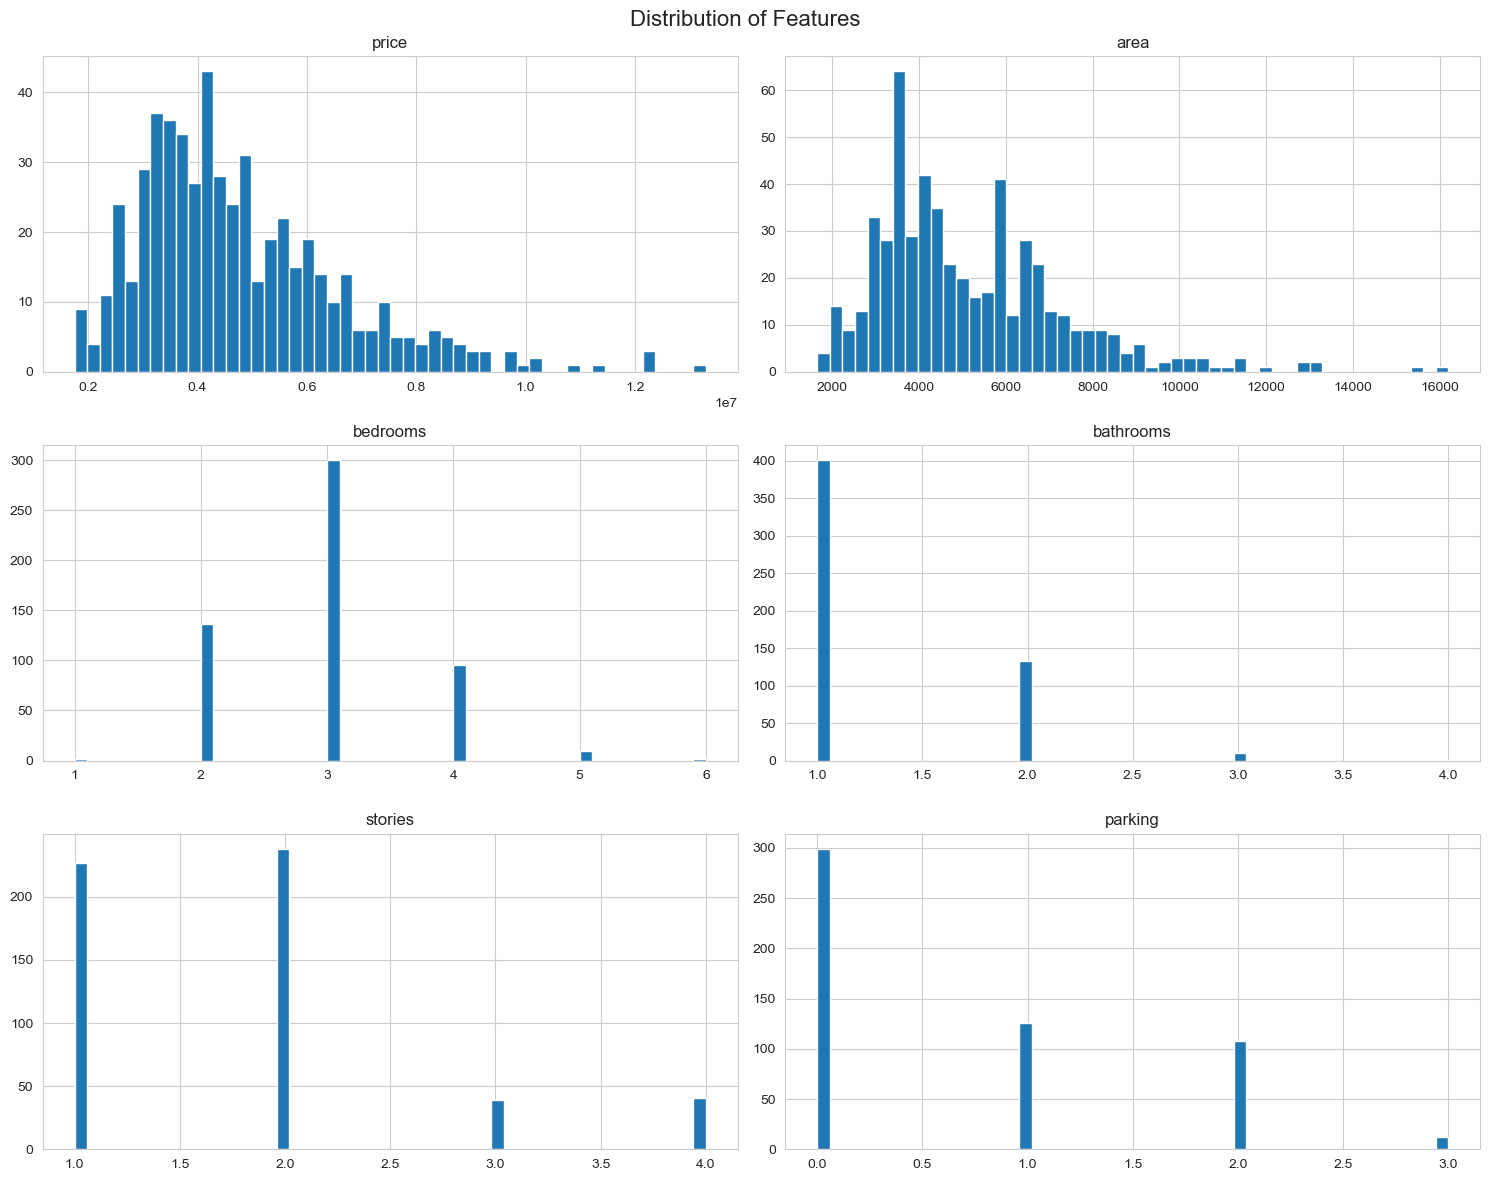

In [26]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols].hist(bins=50, figsize=(15, 12))
plt.suptitle("Distribution of Features", fontsize=16)
plt.tight_layout()
plt.show()

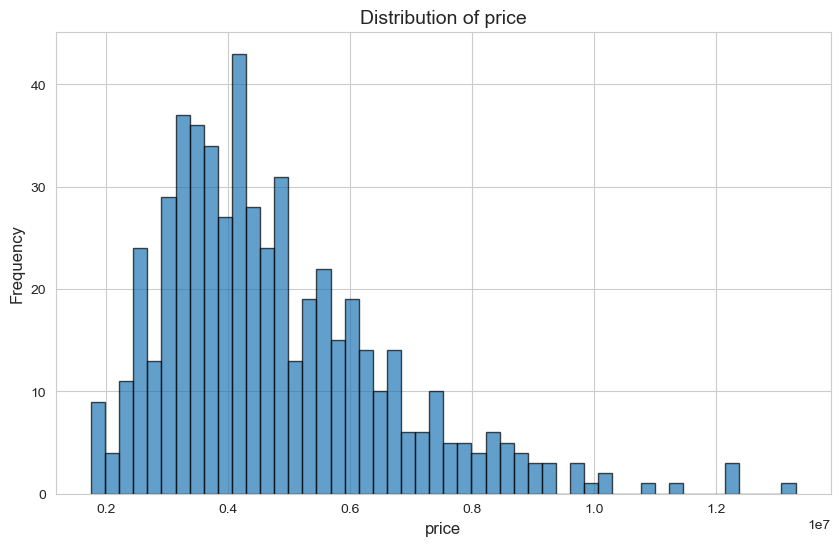


📊 Statistics for 'price':
   Min: 1,750,000
   Max: 13,300,000
   Mean: 4,766,729
   Median: 4,340,000


In [27]:
plt.figure(figsize=(10, 6))
plt.hist(df[target], bins=50, edgecolor='black', alpha=0.7)
plt.xlabel(target, fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title(f'Distribution of {target}', fontsize=14)
plt.show()

print(f"\n📊 Statistics for '{target}':")
print(f"   Min: {df[target].min():,.0f}")
print(f"   Max: {df[target].max():,.0f}")
print(f"   Mean: {df[target].mean():,.0f}")
print(f"   Median: {df[target].median():,.0f}")


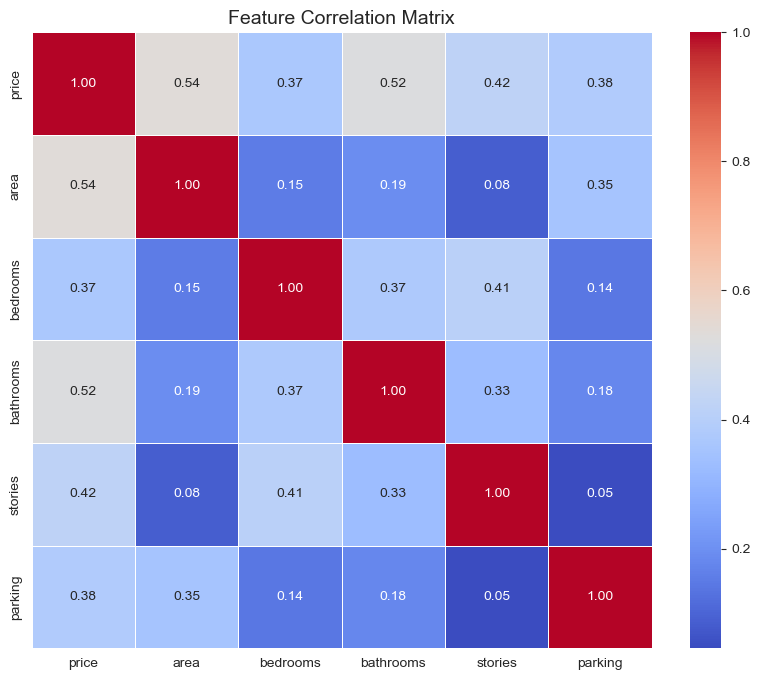


📈 Features most correlated with target:
   area: 0.536
   bathrooms: 0.518
   stories: 0.421
   parking: 0.384
   bedrooms: 0.366


In [28]:
numeric_df = df.select_dtypes(include=[np.number])
correlation = numeric_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Matrix', fontsize=14)
plt.show()

# Features correlated with target
if target in correlation.columns:
    price_corr = correlation[target].sort_values(ascending=False)
    print("\n📈 Features most correlated with target:")
    for feature, corr_value in price_corr.items():
        if feature != target:
            print(f"   {feature}: {corr_value:.3f}")

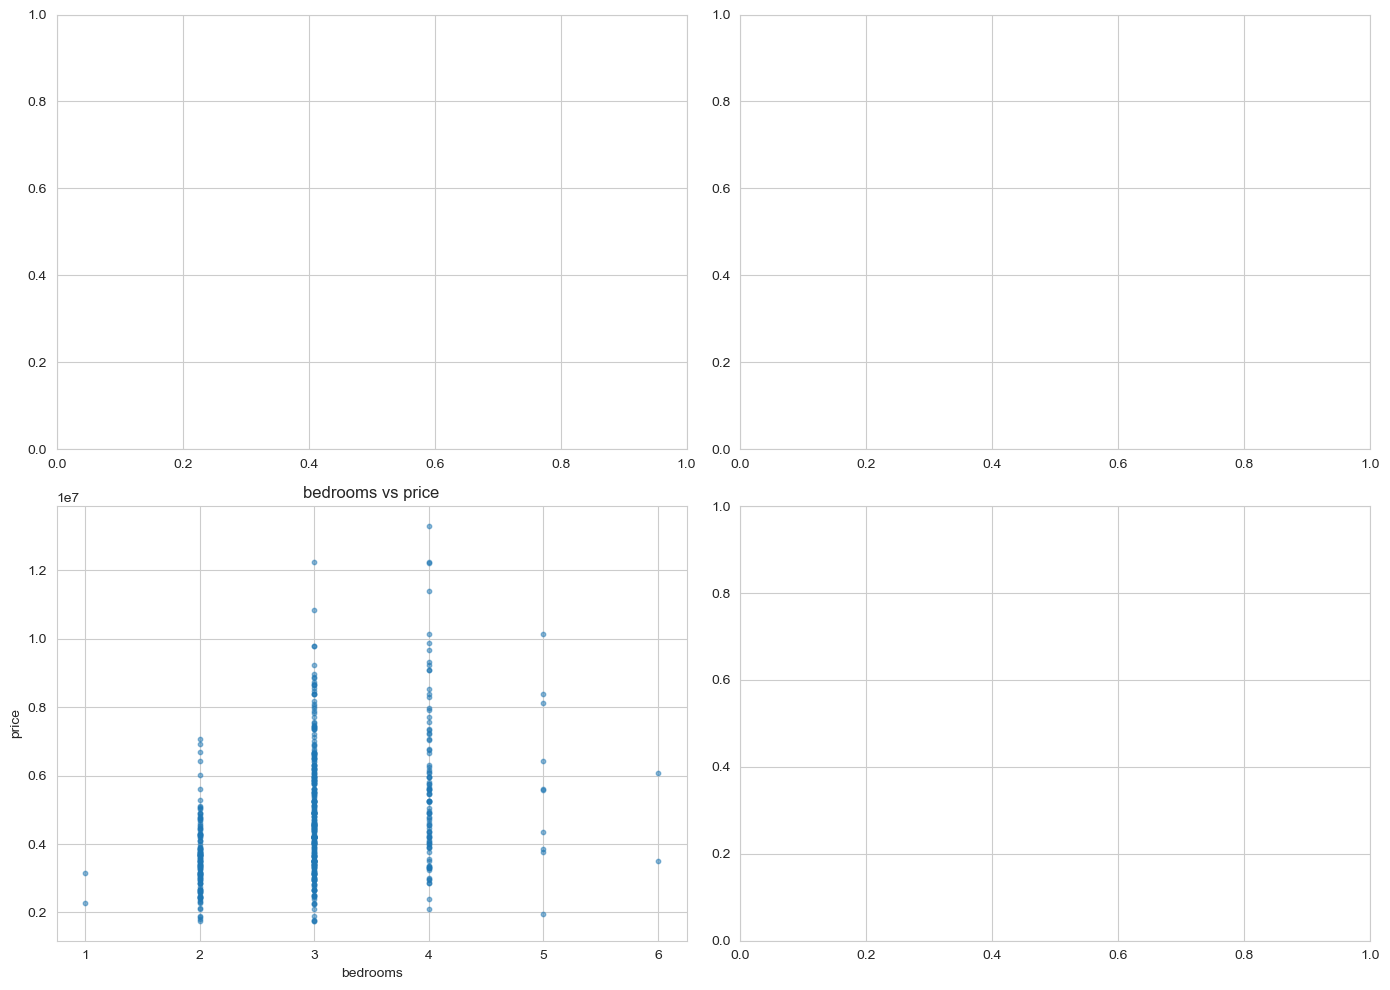

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

if income_col:
    axes[0, 0].scatter(df[income_col], df[target], alpha=0.5, s=10)
    axes[0, 0].set_xlabel(income_col)
    axes[0, 0].set_ylabel(target)
    axes[0, 0].set_title(f'{income_col} vs {target}')

if age_col:
    axes[0, 1].scatter(df[age_col], df[target], alpha=0.5, s=10)
    axes[0, 1].set_xlabel(age_col)
    axes[0, 1].set_ylabel(target)
    axes[0, 1].set_title(f'{age_col} vs {target}')

if rooms_col:
    axes[1, 0].scatter(df[rooms_col], df[target], alpha=0.5, s=10)
    axes[1, 0].set_xlabel(rooms_col)
    axes[1, 0].set_ylabel(target)
    axes[1, 0].set_title(f'{rooms_col} vs {target}')

if population_col:
    axes[1, 1].scatter(df[population_col], df[target], alpha=0.5, s=10)
    axes[1, 1].set_xlabel(population_col)
    axes[1, 1].set_ylabel(target)
    axes[1, 1].set_title(f'{population_col} vs {target}')

plt.tight_layout()
plt.show()

In [30]:
if all([rooms_col, households_col]):
    df['rooms_per_household'] = df[rooms_col] / df[households_col]
    print("✅ Added 'rooms_per_household'")

if all([bedrooms_col, rooms_col]):
    df['bedrooms_per_room'] = df[bedrooms_col] / df[rooms_col]
    print("✅ Added 'bedrooms_per_room'")

if all([population_col, households_col]):
    df['population_per_household'] = df[population_col] / df[households_col]
    print("✅ Added 'population_per_household'")

print(f"\nNew shape: {df.shape}")
df.head()


✅ Added 'bedrooms_per_room'

New shape: (545, 14)


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,bedrooms_per_room
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished,1.0
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished,1.0
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished,1.0
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished,1.0
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished,1.0


In [31]:
if ocean_col:
    print(f"Categories in '{ocean_col}':")
    print(df[ocean_col].value_counts())
    
    # One-hot encode
    df_encoded = pd.get_dummies(df, columns=[ocean_col], drop_first=True)
    print(f"\n✅ Encoded shape: {df_encoded.shape}")
else:
    df_encoded = df.copy()
    print("⚠️ No categorical column found. Using all numeric features.")

df_encoded.head()


⚠️ No categorical column found. Using all numeric features.


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,bedrooms_per_room
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished,1.0
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished,1.0
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished,1.0
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished,1.0
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished,1.0


In [41]:
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"Found categorical columns: {categorical_cols}")

# Convert all categorical columns to numbers using one-hot encoding
if len(categorical_cols) > 0:
    df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
    print(f"✅ Converted {len(categorical_cols)} categorical columns to numbers")
else:
    df_encoded = df.copy()
    print("✅ No categorical columns found")

print(f"\nNew shape: {df_encoded.shape}")
print(f"\nFirst 2 rows of encoded data:")
df_encoded.head(2)

Found categorical columns: ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']
✅ Converted 7 categorical columns to numbers

New shape: (545, 15)

First 2 rows of encoded data:


,price,area,bedrooms,bathrooms,stories,parking,bedrooms_per_room,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,1.0,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,1.0,True,False,False,False,True,False,False,False


In [42]:
target = None
for col in df_encoded.columns:
    if 'value' in col.lower() or 'price' in col.lower():
        target = col
        break

if target is None:
    target = df_encoded.columns[-1]
    print(f"⚠️ Using last column as target: '{target}'")
else:
    print(f"✅ Target column: '{target}'")

# Split features and target
X = df_encoded.drop(target, axis=1)
y = df_encoded[target]

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nAll features are now numeric: {X.dtypes.value_counts().to_dict()}")


✅ Target column: 'price'

Features shape: (545, 14)
Target shape: (545,)

All features are now numeric: {dtype('bool'): 8, dtype('int64'): 5, dtype('float64'): 1}


In [43]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"Number of features: {X_train.shape[1]}")

Training set: 436 samples
Test set: 109 samples
Number of features: 14


In [44]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predictions
y_pred_lr = lr_model.predict(X_test)

# Evaluate
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("="*50)
print("LINEAR REGRESSION RESULTS")
print("="*50)
print(f"Mean Absolute Error (MAE): ${mae_lr:,.0f}")
print(f"Root Mean Square Error (RMSE): ${rmse_lr:,.0f}")
print(f"R² Score: {r2_lr:.4f}")
print("(R² of 1.0 = perfect prediction, 0.0 = random guess)")

LINEAR REGRESSION RESULTS
Mean Absolute Error (MAE): $970,043
Root Mean Square Error (RMSE): $1,324,507
R² Score: 0.6529
(R² of 1.0 = perfect prediction, 0.0 = random guess)


In [45]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluate
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("="*50)
print("RANDOM FOREST RESULTS")
print("="*50)
print(f"Mean Absolute Error (MAE): ${mae_rf:,.0f}")
print(f"Root Mean Square Error (RMSE): ${rmse_rf:,.0f}")
print(f"R² Score: {r2_rf:.4f}")

RANDOM FOREST RESULTS
Mean Absolute Error (MAE): $1,027,390
Root Mean Square Error (RMSE): $1,399,824
R² Score: 0.6123


In [46]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE ($)': [mae_lr, mae_rf],
    'RMSE ($)': [rmse_lr, rmse_rf],
    'R² Score': [r2_lr, r2_rf]
})

print("="*50)
print("MODEL COMPARISON")
print("="*50)
print(results.to_string(index=False))

if r2_rf > r2_lr:
    print(f"\n✅ Random Forest performs better (R²: {r2_rf:.4f} vs {r2_lr:.4f})")
    best_model = "Random Forest"
    best_r2 = r2_rf
    best_mae = mae_rf
else:
    print(f"\n✅ Linear Regression performs better (R²: {r2_lr:.4f} vs {r2_rf:.4f})")
    best_model = "Linear Regression"
    best_r2 = r2_lr
    best_mae = mae_lr

MODEL COMPARISON
            Model      MAE ($)     RMSE ($)  R² Score
Linear Regression 9.700434e+05 1.324507e+06  0.652924
    Random Forest 1.027390e+06 1.399824e+06  0.612330

✅ Linear Regression performs better (R²: 0.6529 vs 0.6123)


TOP 10 MOST IMPORTANT FEATURES
                     Feature  Importance
                        area    0.469538
                   bathrooms    0.151203
         airconditioning_yes    0.062930
                     parking    0.057384
                     stories    0.056606
                    bedrooms    0.048042
furnishingstatus_unfurnished    0.034912
                basement_yes    0.031669
                prefarea_yes    0.030521
         hotwaterheating_yes    0.017754


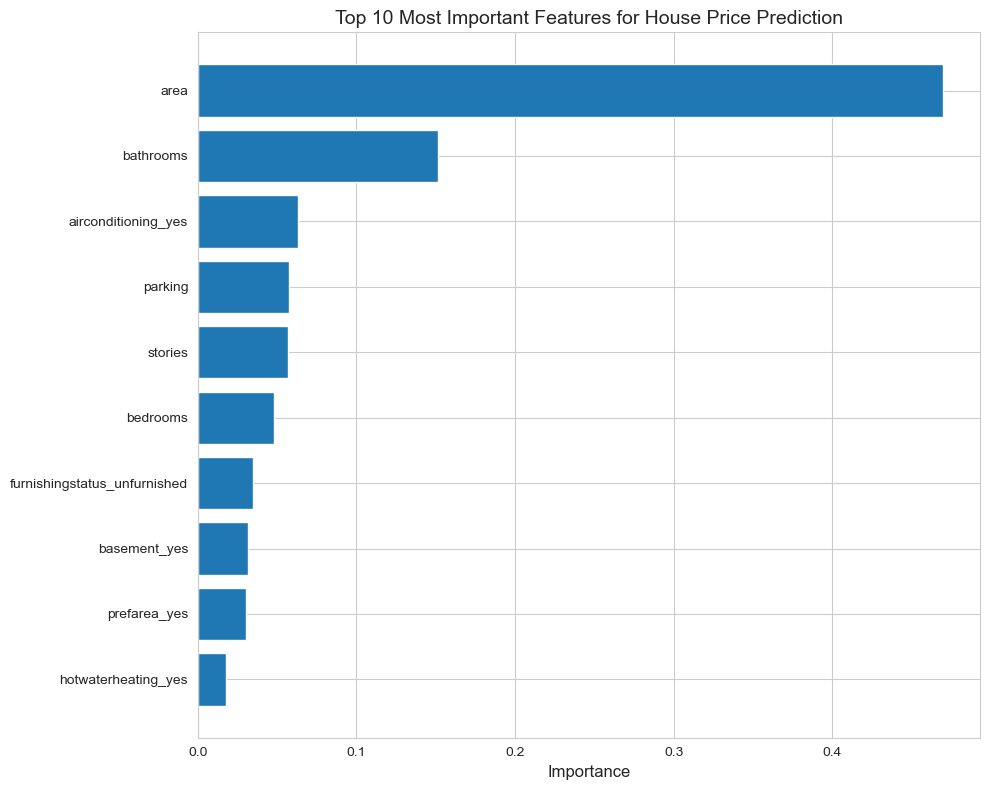

In [47]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("="*50)
print("TOP 10 MOST IMPORTANT FEATURES")
print("="*50)
print(feature_importance.head(10).to_string(index=False))

plt.figure(figsize=(10, 8))
plt.barh(feature_importance.head(10)['Feature'], feature_importance.head(10)['Importance'])
plt.xlabel('Importance', fontsize=12)
plt.title('Top 10 Most Important Features for House Price Prediction', fontsize=14)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

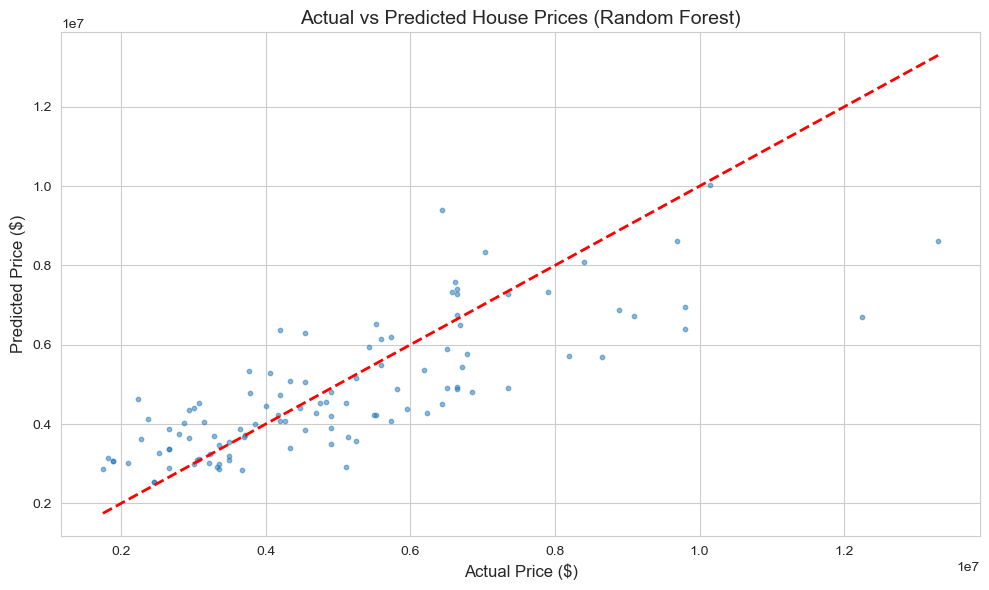

In [48]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.5, s=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price ($)', fontsize=12)
plt.ylabel('Predicted Price ($)', fontsize=12)
plt.title('Actual vs Predicted House Prices (Random Forest)', fontsize=14)
plt.tight_layout()
plt.show()

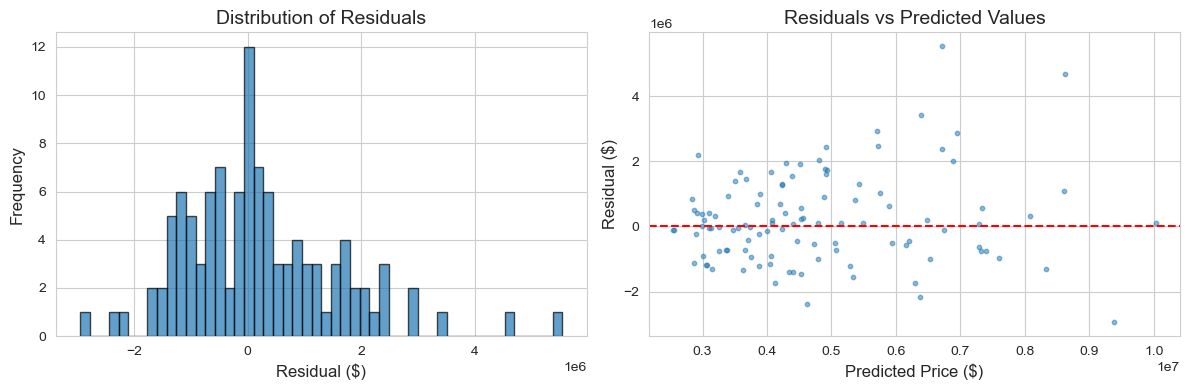

Residual Statistics:
  Mean: $217,865
  Std: $1,389,153


In [49]:
residuals = y_test - y_pred_rf

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(residuals, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Residual ($)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Residuals', fontsize=14)

plt.subplot(1, 2, 2)
plt.scatter(y_pred_rf, residuals, alpha=0.5, s=10)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Price ($)', fontsize=12)
plt.ylabel('Residual ($)', fontsize=12)
plt.title('Residuals vs Predicted Values', fontsize=14)

plt.tight_layout()
plt.show()

print(f"Residual Statistics:")
print(f"  Mean: ${residuals.mean():,.0f}")
print(f"  Std: ${residuals.std():,.0f}")

In [50]:
sample_results = pd.DataFrame({
    'Actual Price': y_test.head(10).values,
    'Predicted Price': y_pred_rf[:10],
    'Difference': y_test.head(10).values - y_pred_rf[:10]
})
sample_results['Error %'] = abs(sample_results['Difference'] / sample_results['Actual Price']) * 100

print("="*50)
print("SAMPLE PREDICTIONS (First 10 Test Samples)")
print("="*50)
print(sample_results.to_string(index=False))
print(f"\n📊 Average Error: {sample_results['Error %'].mean():.1f}%")


SAMPLE PREDICTIONS (First 10 Test Samples)
 Actual Price  Predicted Price  Difference   Error %
      4060000        5286820.0  -1226820.0 30.217241
      6650000        7287980.0   -637980.0  9.593684
      3710000        3733310.0    -23310.0  0.628302
      6440000        4516750.0   1923250.0 29.864130
      2800000        3745385.0   -945385.0 33.763750
      4900000        3500910.0   1399090.0 28.552857
      5250000        5152490.0     97510.0  1.857333
      4543000        5050010.0   -507010.0 11.160247
      2450000        2546880.0    -96880.0  3.954286
      3353000        2861400.5    491599.5 14.661482

📊 Average Error: 16.4%


In [53]:
if r2_rf > r2_lr:
    joblib.dump(rf_model, 'housing_price_model.pkl')
    print("✅ Random Forest model saved as 'housing_price_model.pkl'")
else:
    joblib.dump(lr_model, 'housing_price_model.pkl')
    print("✅ Linear Regression model saved as 'housing_price_model.pkl'")

# Save cleaned data
df_encoded.to_csv('cleaned_housing_data.csv', index=False)
print("✅ Cleaned data saved as 'cleaned_housing_data.csv'")

✅ Linear Regression model saved as 'housing_price_model.pkl'
✅ Cleaned data saved as 'cleaned_housing_data.csv'


In [54]:
new_house = {}

# Use median values from your data
for col in X.columns:
    new_house[col] = X[col].median()

# Convert to DataFrame
new_house_df = pd.DataFrame([new_house])

# Make prediction
predicted_price = rf_model.predict(new_house_df)

print("="*50)
print("SAMPLE PREDICTION")
print("="*50)
print(f"🏠 Predicted house price for a typical house: ${predicted_price[0]:,.0f}")

SAMPLE PREDICTION
🏠 Predicted house price for a typical house: $3,820,390


In [55]:
print("="*60)
print("🏠 HOUSING PRICE PREDICTION - PROJECT SUMMARY")
print("="*60)

print(f"\n📊 DATASET:")
print(f"   Total samples: {len(df)}")
print(f"   Features used: {X.shape[1]}")
print(f"   Target column: '{target}'")

print(f"\n🤖 MODELS TRAINED:")
print(f"   1. Linear Regression - R²: {r2_lr:.4f}")
print(f"   2. Random Forest - R²: {r2_rf:.4f}")

print(f"\n🏆 BEST MODEL: {best_model}")
print(f"   R² Score: {best_r2:.4f}")
print(f"   Mean Absolute Error: ${best_mae:,.0f}")

print(f"\n📈 MOST IMPORTANT FEATURES (from Random Forest):")
for i in range(min(5, len(feature_importance))):
    row = feature_importance.iloc[i]
    print(f"   {i+1}. {row['Feature']}: {row['Importance']:.3f}")

print(f"\n💾 SAVED FILES:")
print(f"   - housing_price_model.pkl (trained model)")
print(f"   - cleaned_housing_data.csv (cleaned dataset)")

print("\n" + "="*60)
print("✅ PROJECT COMPLETED SUCCESSFULLY!")
print("="*60)

🏠 HOUSING PRICE PREDICTION - PROJECT SUMMARY

📊 DATASET:
   Total samples: 545
   Features used: 14
   Target column: 'price'

🤖 MODELS TRAINED:
   1. Linear Regression - R²: 0.6529
   2. Random Forest - R²: 0.6123

🏆 BEST MODEL: Linear Regression
   R² Score: 0.6529
   Mean Absolute Error: $970,043

📈 MOST IMPORTANT FEATURES (from Random Forest):
   1. area: 0.470
   2. bathrooms: 0.151
   3. airconditioning_yes: 0.063
   4. parking: 0.057
   5. stories: 0.057

💾 SAVED FILES:
   - housing_price_model.pkl (trained model)
   - cleaned_housing_data.csv (cleaned dataset)

✅ PROJECT COMPLETED SUCCESSFULLY!
